# B1 + M — Bi-Modal Fine-Tune & Tri-Modal CompRS-CLIP

**Phase 2 of CompRS-CLIP project — main training and benchmarking notebook.** Trains both the bi-modal baseline (B1) and the proposed tri-modal model (M) on the same dataset splits, the same captions, and the same training recipe. The only difference between them is whether the composition MLP and the V-C, T-C losses are present to objectively analyze the research question.

The frozen RemoteCLIP backbone is exercised once per (image, caption-column) at the start to produce a cached feature bank. The training loop then operates entirely on these cached 512-dim features and the trainable projection heads / composition MLP

**Run matrix** (12 runs total):
- Captions: `vision_qwen3-vl-8b` (no comp information), `hybrid_qwen3-vl-8b` (comp baked into text)
- Models: `bimodal` (B1, vision_proj + text_proj + L_VT only), `trimodal` (M, full CompRS-CLIP)
- Seeds: 42, 123, 7

## 0. Setup & Reproducibility

In [1]:
# --- Install extra dependencies ---
!pip install open_clip_torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [2]:
# --- Imports ---
import json
import math
import random
import time
from copy import deepcopy
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import Literal, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import open_clip
from huggingface_hub import hf_hub_download
from sklearn.model_selection import train_test_split

In [3]:
# --- Reproducibility ---
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'Total VRAM   : {total_vram:.1f} GB')
print(f'PyTorch      : {torch.__version__}')
print(f'open_clip    : {open_clip.__version__}')

Device       : cuda
GPU          : Tesla T4
Total VRAM   : 14.6 GB
PyTorch      : 2.10.0+cu128
open_clip    : 3.3.0


## 1. Configuration

`RunConfig` defines a single experiment run; the run matrix is built by varying its three axes (caption, model variant, seed). Hyperparameters are shared across all runs. The only cross-run differences are the three matrix axes themselves. which is by design to answer research question: whether the third modality helps, not whether some HP combination helps.

In [4]:
# --- Dataset paths ---
DATASET_ROOT = Path('/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset')
CSV_PATH     = DATASET_ROOT / 'captions.csv'
IMG_DIR      = DATASET_ROOT / 'images'

# --- Output paths ---
SPLIT_DIR    = Path('splits')
RESULTS_DIR  = Path('results')
FIGURE_DIR   = Path('figures')
for d in [SPLIT_DIR, RESULTS_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SPLIT_CSV    = SPLIT_DIR   / 'comprs_split.csv'
RESULTS_JSON = RESULTS_DIR / 'b1m_results.json'

COMP_COLS = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']

# --- Run matrix axes ---
CAPTIONS = ['vision_qwen3-vl-8b', 'hybrid_qwen3-vl-8b']
MODEL_VARIANTS = ['bimodal', 'trimodal']
SEEDS = [42, 123, 7]

# --- Recall cut-offs ---
K_VALUES = [1, 5, 10]

N_TRAIN, N_VAL, N_TEST = 7000, 1000, 2000
SPLIT_SEED = 42 # identical split seed with B0

assert CSV_PATH.exists(), f'captions.csv not found at {CSV_PATH}'
assert IMG_DIR.exists(),  f'images/ folder not found at {IMG_DIR}'

In [5]:
@dataclass
class RunConfig:
    # Run-matrix axes, vary across runs
    caption: str
    model_variant: Literal['bimodal', 'trimodal']
    seed: int

    # Shared hyperparameters, constant across runs
    epochs: int = 20
    batch_size: int = 32
    lr: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    lambda_vt: float = 1.0
    lambda_vc: float = 1.0
    lambda_tc: float = 1.0
    initial_temp: float = 0.07 # InfoNCE temperature, learnable in log-space
    mlp_hidden: List[int] = field(default_factory=lambda: [128, 256])
    embed_dim: int = 512

    def run_id(self) -> str:
        return f'{self.model_variant}_{self.caption}_seed{self.seed}'

## 2. Canonical Split

If the split CSV from the B0 notebook is present, load it. Otherwise, recompute it using the identical stratification recipe and seed which is is deterministic, so the resulting splits are byte-equivalent to B0's.

In [6]:
df = pd.read_csv(CSV_PATH)
df['dominant_class'] = df[COMP_COLS].values.argmax(axis=1)
df['dominant_class'] = df['dominant_class'].map(lambda i: COMP_COLS[i])
print(f'Total rows: {len(df)}')
print(f'Dominant-class distribution:')
print(df['dominant_class'].value_counts())

Total rows: 10000
Dominant-class distribution:
dominant_class
Grass       4703
Tree        3037
Crop        1803
Barren       193
Water        178
Built-up      59
Shrub         27
Name: count, dtype: int64


In [7]:
# --- Either load existing split or rebuild it deterministically ---
if SPLIT_CSV.exists():
    print(f'Found canonical split at {SPLIT_CSV}; loading.')
    split_df = pd.read_csv(SPLIT_CSV)
else:
    print(f'No canonical split at {SPLIT_CSV}; rebuilding with seed={SPLIT_SEED}.')
    if len(df) > N_TRAIN + N_VAL + N_TEST:
        df_sub, _ = train_test_split(
            df, train_size=N_TRAIN + N_VAL + N_TEST,
            stratify=df['dominant_class'], random_state=SPLIT_SEED,
        )
    else:
        df_sub = df.copy()
    df_trainval, df_test = train_test_split(
        df_sub, test_size=N_TEST,
        stratify=df_sub['dominant_class'], random_state=SPLIT_SEED,
    )
    df_train, df_val = train_test_split(
        df_trainval, test_size=N_VAL,
        stratify=df_trainval['dominant_class'], random_state=SPLIT_SEED,
    )
    df_train = df_train.assign(comprs_split='train')
    df_val   = df_val.assign(comprs_split='val')
    df_test  = df_test.assign(comprs_split='test')
    split_df = (pd.concat([df_train, df_val, df_test], axis=0)
                  .sort_values('filename').reset_index(drop=True)
                  [['filename', 'comprs_split']])
    split_df.to_csv(SPLIT_CSV, index=False)
    print(f'Split saved: {SPLIT_CSV}')

# Merge split assignment back into main df, then build per-split frames
df = df.merge(split_df, on='filename', how='inner')
df_train = df[df['comprs_split'] == 'train'].reset_index(drop=True)
df_val   = df[df['comprs_split'] == 'val'  ].reset_index(drop=True)
df_test  = df[df['comprs_split'] == 'test' ].reset_index(drop=True)
print(f'Train/Val/Test sizes: {len(df_train)} / {len(df_val)} / {len(df_test)}')

Found canonical split at splits/comprs_split.csv; loading.
Train/Val/Test sizes: 7000 / 1000 / 2000


## 3. Load Frozen RemoteCLIP-ViT-B/32

Same recipe as B0: Checkpoint into an `open_clip` ViT-B/32, all parameters frozen.

In [ ]:
# --- Just like the Proof of concept and B0 notebook, initialize RemoteCLIP from the official github repo guide ---
# https://github.com/ChenDelong1999/RemoteCLIP#load-remoteclip
# Download RemoteCLIP checkpoint
print('Downloading RemoteCLIP-ViT-B-32 weights from HuggingFace...')
checkpoint_path = hf_hub_download(
    repo_id='chendelong/RemoteCLIP',
    filename='RemoteCLIP-ViT-B-32.pt',
    cache_dir='checkpoints',
)
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32')
clip_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_model = clip_model.to(DEVICE)
for p in clip_model.parameters():
    p.requires_grad = False
clip_model.eval()
print('RemoteCLIP-ViT-B/32 loaded and frozen.')

# I have mistakenly run this cell afterwards while formatting, so removed its error output
# It works as is it does in B0 notebook

## 4. Precomputed Feature Cache

The backbone is frozen, so the raw 512-dim features for every image and every (image, caption-column) pair are constant across all 12 training runs. Compute them once here and cache them as CPU tensors. The training loop then loads cached features by index. One matmul through the projection head, one through the comp MLP, no ViT in the hot path.

Cache layout:
- `image_features[split]` — `(N_split, 512)` raw image features per split (train/val/test)
- `text_features[split][caption_col]` — `(N_split, 512)` raw text features per split per caption
- `comp_vectors[split]` — `(N_split, 7)` normalized composition vectors per split

In [9]:
class _SplitImageDataset(Dataset):
    """Used only during precomputation. Returns image tensors in canonical row order."""
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = self.img_dir / self.df.iloc[idx]["filename"]
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new("RGB", (224, 224), (0, 0, 0))
        return self.transform(image), idx

In [10]:
@torch.no_grad()
def precompute_image_features(df_split, img_dir, transform, model, device, batch_size=64):
    """Encode all images in a split, return (N, 512) L2-normalized CPU tensor."""
    ds = _SplitImageDataset(df_split, img_dir, transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    chunks = []
    for imgs, _ in dl:
        imgs = imgs.to(device, non_blocking=True)
        feat = model.encode_image(imgs)
        feat = F.normalize(feat, dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

@torch.no_grad()
def precompute_text_features(captions, tokenizer, model, device, batch_size=64):
    """Encode all caption strings, return (N, 512) L2-normalized CPU tensor."""
    chunks = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i + batch_size]
        tokens = tokenizer(batch).to(device)
        feat = model.encode_text(tokens)
        feat = F.normalize(feat, dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

def composition_to_tensor(df_split, comp_cols):
    """Extract composition columns and normalize to [0, 1]."""
    raw = df_split[comp_cols].values.astype(np.float32) / 100.0
    return torch.from_numpy(raw)

In [11]:
# --- Build the full feature cache ---
SPLITS = {"train": df_train, "val": df_val, "test": df_test}

print("Precomputing image features per split...")
image_features = {}
t0 = time.time()
for name, dfs in SPLITS.items():
    image_features[name] = precompute_image_features(
        dfs, IMG_DIR, clip_preprocess, clip_model, DEVICE
    )
    print(f"  {name:>5}: {tuple(image_features[name].shape)}")
print(f"Image features done in {time.time() - t0:.1f}s\n")

print("Precomputing text features per split per caption column...")
text_features = {name: {} for name in SPLITS}
t0 = time.time()
for caption_col in CAPTIONS:
    for name, dfs in SPLITS.items():
        captions = dfs[caption_col].astype(str).tolist()
        text_features[name][caption_col] = precompute_text_features(
            captions, clip_tokenizer, clip_model, DEVICE
        )
    print(f"  {caption_col} done")
print(f"Text features done in {time.time() - t0:.1f}s\n")

print("Building composition vector tensors...")
comp_vectors = {name: composition_to_tensor(dfs, COMP_COLS) for name, dfs in SPLITS.items()}
for name, t in comp_vectors.items():
    print(f"  {name:>5}: {tuple(t.shape)}  range=[{t.min():.2f}, {t.max():.2f}]")
print("\nFeature cache ready.")

Precomputing image features per split...
  train: (7000, 512)
    val: (1000, 512)
   test: (2000, 512)
Image features done in 56.9s

Precomputing text features per split per caption column...
  vision_qwen3-vl-8b done
  hybrid_qwen3-vl-8b done
Text features done in 40.7s

Building composition vector tensors...
  train: (7000, 7)  range=[0.00, 1.00]
    val: (1000, 7)  range=[0.00, 1.00]
   test: (2000, 7)  range=[0.00, 1.00]

Feature cache ready.


## 5. Model Components

Three trainable pieces:
- `vision_proj` — `Linear(512, 512, bias=False)`, identity-initialized so training begins from the pretrained RemoteCLIP geometry.
- `text_proj` — same as vision_proj, applied to text features.
- `comp_mlp` — only instantiated for `model_variant='trimodal'`. Maps the 7-dim composition vector to the shared 512-dim space.

A learnable `log_tau` scalar controls the InfoNCE softmax temperature. Initialized so that `tau = 1/0.07 ≈ 14.29`, the canonical CLIP starting point.

In [13]:
class CompositionMLP(nn.Module):
    """Maps a 7-dim composition vector (Tree..Water in [0, 1]) into the 512-dim CLIP space."""
    def __init__(self, in_dim=7, hidden=(128, 256), out_dim=512):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def build_run_components(cfg: RunConfig, device):
    """Instantiate trainable components for a single run, identity-init projections."""
    vision_proj = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    text_proj   = nn.Linear(cfg.embed_dim, cfg.embed_dim, bias=False).to(device)
    nn.init.eye_(vision_proj.weight)
    nn.init.eye_(text_proj.weight)

    log_tau = nn.Parameter(
        torch.tensor(math.log(1.0 / cfg.initial_temp), dtype=torch.float32, device=device)
    )

    if cfg.model_variant == "trimodal":
        comp_mlp = CompositionMLP(in_dim=7, hidden=cfg.mlp_hidden, out_dim=cfg.embed_dim).to(device)
    else:
        comp_mlp = None

    params = list(vision_proj.parameters()) + list(text_proj.parameters()) + [log_tau]
    if comp_mlp is not None:
        params += list(comp_mlp.parameters())

    return vision_proj, text_proj, comp_mlp, log_tau, params

## 6. Loss Function

For `bimodal`, only `L_VT` is active. For `trimodal`, the full tri-modal InfoNCE is used with weights `λ1=λ2=λ3=1.0`.

In [15]:
def symmetric_infonce(A, B, log_tau):
    """Symmetric cross-entropy InfoNCE on cosine similarity matrix between two embeddings."""
    N = A.shape[0]
    targets = torch.arange(N, device=A.device)
    tau = log_tau.exp()
    sim = (A @ B.T) * tau
    loss_ab = F.cross_entropy(sim, targets)
    loss_ba = F.cross_entropy(sim.T, targets)
    return 0.5 * (loss_ab + loss_ba)

def compute_loss(E_v, E_t, E_c, log_tau, cfg: RunConfig):
    """Returns (L_total, L_VT, L_VC, L_TC). For bimodal, L_VC and L_TC are zero tensors."""
    L_VT = symmetric_infonce(E_v, E_t, log_tau)
    if cfg.model_variant == "trimodal":
        L_VC = symmetric_infonce(E_v, E_c, log_tau)
        L_TC = symmetric_infonce(E_t, E_c, log_tau)
        L_total = cfg.lambda_vt * L_VT + cfg.lambda_vc * L_VC + cfg.lambda_tc * L_TC
    else:
        zero = torch.zeros((), device=E_v.device)
        L_VC, L_TC = zero, zero
        L_total = cfg.lambda_vt * L_VT
    return L_total, L_VT, L_VC, L_TC

## 7. Cached-Feature Dataset & Retrieval Evaluator

`CachedFeatureDataset` returns indexed slices of the precomputed cache; no I/O, no encoder calls. `evaluate_retrieval` projects the cached val/test features through the current projection heads and computes Recall@K.

In [16]:
class CachedFeatureDataset(Dataset):
    """Returns (raw_image_feature, raw_text_feature, comp_vector) for one row."""
    def __init__(self, raw_img, raw_txt, comp):
        assert len(raw_img) == len(raw_txt) == len(comp), "Cached tensors must align row-wise"
        self.raw_img = raw_img
        self.raw_txt = raw_txt
        self.comp = comp
    def __len__(self):
        return len(self.raw_img)
    def __getitem__(self, idx):
        return self.raw_img[idx], self.raw_txt[idx], self.comp[idx]

In [17]:
def retrieval_metrics(img_embs, txt_embs, k_values=(1, 5, 10)):
    assert img_embs.shape == txt_embs.shape
    N = img_embs.shape[0]
    sim = img_embs @ txt_embs.T
    targets = torch.arange(N)
    out = {}
    for k in k_values:
        topk = sim.topk(k, dim=1).indices
        hits = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item()
        out[f"i2t_R@{k}"] = hits * 100
    sim_t = sim.T
    for k in k_values:
        topk = sim_t.topk(k, dim=1).indices
        hits = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item()
        out[f"t2i_R@{k}"] = hits * 100
    out["mR"] = float(np.mean([out[f"i2t_R@{k}"] for k in k_values] +
                              [out[f"t2i_R@{k}"] for k in k_values]))
    return out

@torch.no_grad()
def evaluate_split(vision_proj, text_proj, raw_img, raw_txt, device, k_values=(1, 5, 10)):
    """Project cached raw features through current heads, compute Recall@K."""
    vision_proj.eval()
    text_proj.eval()
    raw_img = raw_img.to(device)
    raw_txt = raw_txt.to(device)
    E_v = F.normalize(vision_proj(raw_img), dim=-1).cpu()
    E_t = F.normalize(text_proj(raw_txt), dim=-1).cpu()
    return retrieval_metrics(E_v, E_t, k_values)

## 8. Training Loop

Per run: 20 epochs of AdamW + cosine LR decay over the cached training features. Validation mR is computed at every epoch and the best-on-val parameter snapshot is restored before final test evaluation.

In [18]:
def state_snapshot(vision_proj, text_proj, comp_mlp, log_tau):
    """Detached deep copy of all trainable parameters for best-on-val checkpointing."""
    snap = {
        "vision_proj": deepcopy(vision_proj.state_dict()),
        "text_proj":   deepcopy(text_proj.state_dict()),
        "log_tau":     log_tau.detach().clone(),
    }
    if comp_mlp is not None:
        snap["comp_mlp"] = deepcopy(comp_mlp.state_dict())
    return snap

def state_restore(snap, vision_proj, text_proj, comp_mlp, log_tau):
    vision_proj.load_state_dict(snap["vision_proj"])
    text_proj.load_state_dict(snap["text_proj"])
    log_tau.data.copy_(snap["log_tau"])
    if comp_mlp is not None and "comp_mlp" in snap:
        comp_mlp.load_state_dict(snap["comp_mlp"])

In [19]:
def train_one_run(cfg: RunConfig, image_features, text_features, comp_vectors, device):
    """
    Run a single training experiment end-to-end. Returns dict with:
      history          : per-epoch loss components and val mR
      test_metrics     : final R@K on the test set using best-val checkpoint
      best_val_mR      : best validation mR observed during training
      epoch_seconds    : wall-clock per epoch
    """
    set_seed(cfg.seed)
    vision_proj, text_proj, comp_mlp, log_tau, params = build_run_components(cfg, device)

    # Build cached dataloader for this caption column
    train_ds = CachedFeatureDataset(
        image_features["train"],
        text_features["train"][cfg.caption],
        comp_vectors["train"],
    )
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=0, pin_memory=False, drop_last=True,
    )

    optimizer = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    history = {
        "epoch": [], "L_total": [], "L_VT": [], "L_VC": [], "L_TC": [],
        "val_mR": [], "lr": [], "tau": [],
    }
    best_val_mR = -1.0
    best_snapshot = None
    epoch_seconds = []

    for epoch in range(1, cfg.epochs + 1):
        t_epoch = time.time()
        vision_proj.train(); text_proj.train()
        if comp_mlp is not None:
            comp_mlp.train()

        ep_losses = {"L_total": [], "L_VT": [], "L_VC": [], "L_TC": []}

        for raw_v, raw_t, comp in train_loader:
            raw_v = raw_v.to(device, non_blocking=True)
            raw_t = raw_t.to(device, non_blocking=True)
            comp  = comp.to(device, non_blocking=True)

            E_v = F.normalize(vision_proj(raw_v), dim=-1)
            E_t = F.normalize(text_proj(raw_t), dim=-1)
            E_c = comp_mlp(comp) if comp_mlp is not None else None

            L_total, L_VT, L_VC, L_TC = compute_loss(E_v, E_t, E_c, log_tau, cfg)

            optimizer.zero_grad()
            L_total.backward()
            torch.nn.utils.clip_grad_norm_(params, cfg.grad_clip)
            optimizer.step()

            ep_losses["L_total"].append(L_total.item())
            ep_losses["L_VT"].append(L_VT.item())
            ep_losses["L_VC"].append(L_VC.item())
            ep_losses["L_TC"].append(L_TC.item())

        scheduler.step()

        # Validation
        val_metrics = evaluate_split(
            vision_proj, text_proj,
            image_features["val"], text_features["val"][cfg.caption],
            device,
        )

        history["epoch"].append(epoch)
        history["L_total"].append(float(np.mean(ep_losses["L_total"])))
        history["L_VT"].append(float(np.mean(ep_losses["L_VT"])))
        history["L_VC"].append(float(np.mean(ep_losses["L_VC"])))
        history["L_TC"].append(float(np.mean(ep_losses["L_TC"])))
        history["val_mR"].append(val_metrics["mR"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["tau"].append(float(log_tau.exp().item()))

        if val_metrics["mR"] > best_val_mR:
            best_val_mR = val_metrics["mR"]
            best_snapshot = state_snapshot(vision_proj, text_proj, comp_mlp, log_tau)

        epoch_seconds.append(time.time() - t_epoch)

    # Restore best-on-val and evaluate test
    state_restore(best_snapshot, vision_proj, text_proj, comp_mlp, log_tau)
    test_metrics = evaluate_split(
        vision_proj, text_proj,
        image_features["test"], text_features["test"][cfg.caption],
        device,
    )

    return {
        "history": history,
        "test_metrics": test_metrics,
        "best_val_mR": best_val_mR,
        "epoch_seconds": epoch_seconds,
    }

## 9. Execute the Run Matrix

Loops over caption × model_variant × seed = 12 runs.

In [20]:
all_runs = []
total_runs = len(CAPTIONS) * len(MODEL_VARIANTS) * len(SEEDS)
run_idx = 0
total_t0 = time.time()

for caption in CAPTIONS:
    for model_variant in MODEL_VARIANTS:
        for seed in SEEDS:
            run_idx += 1
            cfg = RunConfig(caption=caption, model_variant=model_variant, seed=seed)
            print(f"\n[{run_idx}/{total_runs}] {cfg.run_id()}")

            run_t0 = time.time()
            result = train_one_run(cfg, image_features, text_features, comp_vectors, DEVICE)
            run_dur = time.time() - run_t0

            print(f"  best val mR = {result['best_val_mR']:.2f}")
            tm = result["test_metrics"]
            print(f"  test  mR    = {tm['mR']:.2f}  "
                  f"(I2T R@1={tm['i2t_R@1']:.2f} R@5={tm['i2t_R@5']:.2f} R@10={tm['i2t_R@10']:.2f}, "
                  f"T2I R@1={tm['t2i_R@1']:.2f} R@5={tm['t2i_R@5']:.2f} R@10={tm['t2i_R@10']:.2f})")
            print(f"  duration    = {run_dur:.1f}s ({np.mean(result['epoch_seconds']):.2f}s/epoch)")

            all_runs.append({
                "config": asdict(cfg),
                "run_id": cfg.run_id(),
                "test_metrics": result["test_metrics"],
                "best_val_mR": result["best_val_mR"],
                "history": result["history"],
                "duration_s": run_dur,
            })

print(f"\nAll {total_runs} runs complete in {(time.time() - total_t0) / 60:.1f} minutes.")


[1/12] bimodal_vision_qwen3-vl-8b_seed42
  best val mR = 27.40
  test  mR    = 17.54  (I2T R@1=5.95 R@5=17.80 R@10=28.15, T2I R@1=6.20 R@5=19.55 R@10=27.60)
  duration    = 15.1s (0.75s/epoch)

[2/12] bimodal_vision_qwen3-vl-8b_seed123
  best val mR = 27.27
  test  mR    = 17.43  (I2T R@1=5.65 R@5=18.25 R@10=28.25, T2I R@1=5.65 R@5=18.55 R@10=28.25)
  duration    = 14.5s (0.72s/epoch)

[3/12] bimodal_vision_qwen3-vl-8b_seed7
  best val mR = 27.22
  test  mR    = 17.78  (I2T R@1=5.55 R@5=18.65 R@10=29.10, T2I R@1=5.75 R@5=19.30 R@10=28.30)
  duration    = 14.6s (0.73s/epoch)

[4/12] trimodal_vision_qwen3-vl-8b_seed42
  best val mR = 27.58
  test  mR    = 17.80  (I2T R@1=5.10 R@5=19.30 R@10=28.80, T2I R@1=5.75 R@5=19.05 R@10=28.80)
  duration    = 24.7s (1.23s/epoch)

[5/12] trimodal_vision_qwen3-vl-8b_seed123
  best val mR = 27.43
  test  mR    = 17.60  (I2T R@1=5.65 R@5=18.25 R@10=28.85, T2I R@1=5.65 R@5=18.20 R@10=29.00)
  duration    = 24.8s (1.23s/epoch)

[6/12] trimodal_vision_qwe

## 10. Aggregate Results

Build a tidy DataFrame across the 12 runs, then collapse seeds to mean plus/minus std for the report's main results table. Also pulls in the B0 zero-shot numbers if `results/b0_zeroshot.json` is present.

In [21]:
# --- Flat per-run dataframe ---
rows = []
for r in all_runs:
    row = {
        "caption": r["config"]["caption"],
        "model": r["config"]["model_variant"],
        "seed":  r["config"]["seed"],
        "best_val_mR": r["best_val_mR"],
        **r["test_metrics"],
    }
    rows.append(row)
runs_df = pd.DataFrame(rows)
print("Per-run results:")
print(runs_df.to_string(index=False))

Per-run results:
           caption    model  seed  best_val_mR  i2t_R@1   i2t_R@5  i2t_R@10  t2i_R@1   t2i_R@5  t2i_R@10        mR
vision_qwen3-vl-8b  bimodal    42    27.400000     5.95 17.800000 28.150001     6.20 19.550000 27.599999 17.541667
vision_qwen3-vl-8b  bimodal   123    27.266667     5.65 18.250000 28.250000     5.65 18.550000 28.250000 17.433333
vision_qwen3-vl-8b  bimodal     7    27.216667     5.55 18.650000 29.100001     5.75 19.300000 28.299999 17.775000
vision_qwen3-vl-8b trimodal    42    27.583334     5.10 19.300000 28.799999     5.75 19.050001 28.799999 17.800000
vision_qwen3-vl-8b trimodal   123    27.433333     5.65 18.250000 28.850001     5.65 18.200000 28.999999 17.600000
vision_qwen3-vl-8b trimodal     7    27.816667     6.10 19.149999 29.249999     5.75 18.200000 29.049999 17.916666
hybrid_qwen3-vl-8b  bimodal    42    23.816667     4.45 16.000000 26.699999     4.40 16.050000 27.599999 15.866666
hybrid_qwen3-vl-8b  bimodal   123    24.500000     5.00 16.5500

In [22]:
# --- Mean +- std across the 3 seeds ---
metric_cols = ["i2t_R@1", "i2t_R@5", "i2t_R@10", "t2i_R@1", "t2i_R@5", "t2i_R@10", "mR"]
agg = runs_df.groupby(["caption", "model"])[metric_cols].agg(["mean", "std"]).round(2)
print("\nAggregated (mean +- std across 3 seeds):")
print(agg.to_string())


Aggregated (mean +- std across 3 seeds):
                            i2t_R@1       i2t_R@5       i2t_R@10       t2i_R@1       t2i_R@5       t2i_R@10           mR      
                               mean   std    mean   std     mean   std    mean   std    mean   std     mean   std   mean   std
caption            model                                                                                                      
hybrid_qwen3-vl-8b bimodal     4.65  0.30   16.38  0.33    26.43  0.55    4.63  0.36   16.87  0.74    27.70  0.41  16.11  0.25
                   trimodal    4.87  0.32   17.88  0.45    28.20  0.53    5.15  0.23   18.72  0.38    29.33  0.44  17.36  0.33
vision_qwen3-vl-8b bimodal     5.72  0.21   18.23  0.43    28.50  0.52    5.87  0.29   19.13  0.52    28.05  0.39  17.58  0.17
                   trimodal    5.62  0.50   18.90  0.57    28.97  0.25    5.72  0.06   18.48  0.49    28.95  0.13  17.77  0.16


In [23]:
# --- Pull in B0 zero-shot for the unified table, if available ---
B0_PATH = Path("results/b0_zeroshot.json")
if B0_PATH.exists():
    with open(B0_PATH) as f:
        b0 = json.load(f)
    b0_rows = []
    for caption in CAPTIONS:
        if caption in b0["per_caption"]:
            m = b0["per_caption"][caption]
            b0_rows.append({"caption": caption, "model": "B0_zeroshot", **m})
    b0_df = pd.DataFrame(b0_rows)
    print("B0 zero-shot rows aligned to current caption set:")
    print(b0_df.to_string(index=False))
else:
    b0_df = None
    print("B0 results JSON not present; main table will only include B1/M.")

B0 results JSON not present; main table will only include B1/M.


## 11. Figures for the Report

Two figures: an mR comparison bar chart across (caption × model) and a representative loss-curve panel for the trimodal runs.

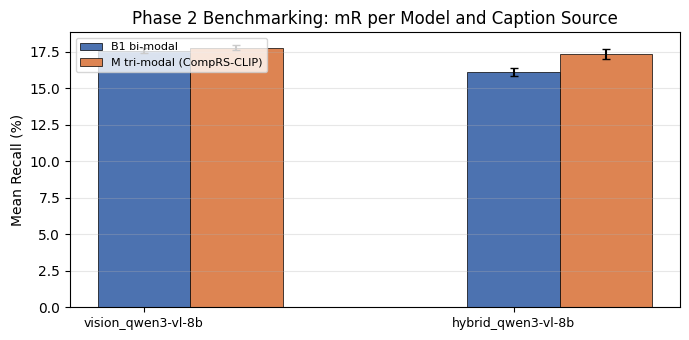

Figure saved: figures/b1m_mR_comparison.png


In [24]:
# --- Figure 1: mR comparison (B0/B1/M x 2 captions) ---
fig, ax = plt.subplots(figsize=(7, 3.5))

caption_labels = CAPTIONS
x = np.arange(len(caption_labels))
width = 0.25

# B0 zero-shot bars (if available)
if b0_df is not None:
    b0_mrs = [b0_df[b0_df["caption"] == c]["mR"].values[0] for c in caption_labels]
    ax.bar(x - width, b0_mrs, width, label="B0 zero-shot", color="#888888",
           edgecolor="black", linewidth=0.5, hatch="//")

# B1 bi-modal bars (mean over seeds, std as error bar)
b1_means = [runs_df[(runs_df["caption"] == c) & (runs_df["model"] == "bimodal")]["mR"].mean()
            for c in caption_labels]
b1_stds = [runs_df[(runs_df["caption"] == c) & (runs_df["model"] == "bimodal")]["mR"].std()
           for c in caption_labels]
ax.bar(x, b1_means, width, yerr=b1_stds, label="B1 bi-modal", color="#4C72B0",
       edgecolor="black", linewidth=0.5, capsize=3)

# M tri-modal bars
m_means = [runs_df[(runs_df["caption"] == c) & (runs_df["model"] == "trimodal")]["mR"].mean()
           for c in caption_labels]
m_stds = [runs_df[(runs_df["caption"] == c) & (runs_df["model"] == "trimodal")]["mR"].std()
          for c in caption_labels]
ax.bar(x + width, m_means, width, yerr=m_stds, label="M tri-modal (CompRS-CLIP)",
       color="#DD8452", edgecolor="black", linewidth=0.5, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(caption_labels, fontsize=9)
ax.set_ylabel("Mean Recall (%)")
ax.set_title("Phase 2 Benchmarking: mR per Model and Caption Source")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "b1m_mR_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'b1m_mR_comparison.png'}")

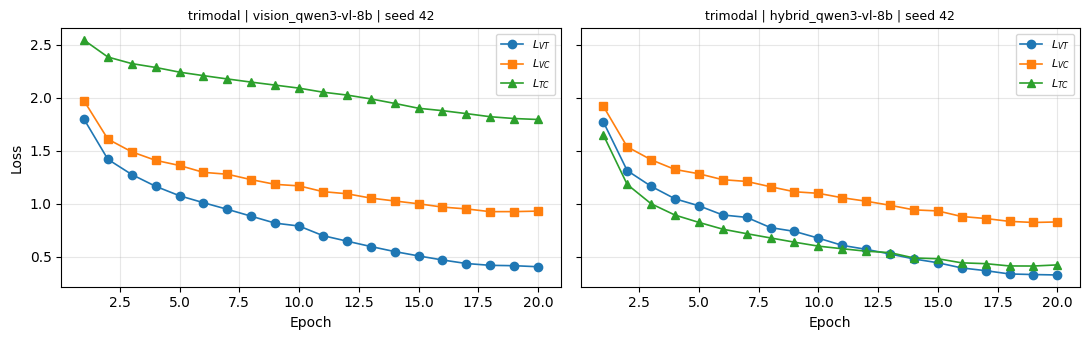

Figure saved: figures/b1m_loss_curves.png


In [25]:
# --- Figure 2: loss curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

for ax, caption in zip(axes, CAPTIONS):
    # Pick the seed-42 trimodal run for visualization
    target = next((r for r in all_runs
                   if r["config"]["caption"] == caption
                   and r["config"]["model_variant"] == "trimodal"
                   and r["config"]["seed"] == 42), None)
    if target is None:
        continue
    hist = target["history"]
    ax.plot(hist["epoch"], hist["L_VT"], marker="o", label="$L_{VT}$", linewidth=1.2)
    ax.plot(hist["epoch"], hist["L_VC"], marker="s", label="$L_{VC}$", linewidth=1.2)
    ax.plot(hist["epoch"], hist["L_TC"], marker="^", label="$L_{TC}$", linewidth=1.2)
    ax.set_title(f"trimodal | {caption} | seed 42", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Loss")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "b1m_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'b1m_loss_curves.png'}")

## 12. Save All Results

In [26]:
final = {
    "model_family": "RemoteCLIP-ViT-B/32 (frozen) + projection heads (B1) / + composition MLP (M)",
    "test_set_size": int(len(image_features["test"])),
    "k_values": K_VALUES,
    "captions": CAPTIONS,
    "model_variants": MODEL_VARIANTS,
    "seeds": SEEDS,
    "split_csv": str(SPLIT_CSV),
    "runs": all_runs,
    "aggregated_table": {
        "columns": list(agg.columns.map("_".join)),
        "rows": [
            {"caption": idx[0], "model": idx[1], **dict(zip(agg.columns.map("_".join), agg.loc[idx].values))}
            for idx in agg.index
        ],
    },
}

with open(RESULTS_JSON, "w") as f:
    json.dump(final, f, indent=2, default=lambda o: float(o) if hasattr(o, "item") else str(o))
print(f"Results saved: {RESULTS_JSON}")

Results saved: results/b1m_results.json
